# 01 — Exploratory Data Analysis (EDA)

**Датасет:** Ethereum Fraud Detection Dataset  
**Целевая переменная:** `FLAG` (1 = фрод, 0 = легитимный)  

## Содержание
1. Загрузка и первичный осмотр  
2. Проверка пропусков и дубликатов  
3. Распределение целевой переменной  
4. **Распределения признаков (гистограммы)**  
5. **Boxplot для выявления выбросов**  
6. Корреляционная матрица  
7. **Зависимость признаков от целевой переменной (фрод vs не-фрод)**  
8. Выводы  

In [1]:
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

os.makedirs('../report/images', exist_ok=True)
print('Готово к работе')

Готово к работе


In [2]:
# ── 1. Загрузка данных ────────────────────────────────────────────────────
df = pd.read_csv('../data/raw/transaction_dataset.csv')

# Нормализация названий колонок
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace('.', '_', regex=False)
)

print(f'Размер: {df.shape}')
print(f'Колонки: {list(df.columns)}')
df.head(3)

Размер: (9841, 51)
Колонки: ['unnamed:_0', 'index', 'address', 'flag', 'avg_min_between_sent_tnx', 'avg_min_between_received_tnx', 'time_diff_between_first_and_last_(mins)', 'sent_tnx', 'received_tnx', 'number_of_created_contracts', 'unique_received_from_addresses', 'unique_sent_to_addresses', 'min_value_received', 'max_value_received', 'avg_val_received', 'min_val_sent', 'max_val_sent', 'avg_val_sent', 'min_value_sent_to_contract', 'max_val_sent_to_contract', 'avg_value_sent_to_contract', 'total_transactions_(including_tnx_to_create_contract', 'total_ether_sent', 'total_ether_received', 'total_ether_sent_contracts', 'total_ether_balance', 'total_erc20_tnxs', 'erc20_total_ether_received', 'erc20_total_ether_sent', 'erc20_total_ether_sent_contract', 'erc20_uniq_sent_addr', 'erc20_uniq_rec_addr', 'erc20_uniq_sent_addr_1', 'erc20_uniq_rec_contract_addr', 'erc20_avg_time_between_sent_tnx', 'erc20_avg_time_between_rec_tnx', 'erc20_avg_time_between_rec_2_tnx', 'erc20_avg_time_between_contrac

,unnamed:_0,index,address,flag,avg_min_between_sent_tnx,avg_min_between_received_tnx,time_diff_between_first_and_last_(mins),sent_tnx,received_tnx,number_of_created_contracts,...,erc20_min_val_sent,erc20_max_val_sent,erc20_avg_val_sent,erc20_min_val_sent_contract,erc20_max_val_sent_contract,erc20_avg_val_sent_contract,erc20_uniq_sent_token_name,erc20_uniq_rec_token_name,erc20_most_sent_token_type,erc20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON


In [3]:
# Базовая статистика
df.describe().T

,count,mean,std,min,25%,50%,75%,max
unnamed:_0,9841.0,4.920000e+03,2.840996e+03,0.00,2460.000000,4.920000e+03,7380.000000,9.840000e+03
index,9841.0,1.815050e+03,1.222622e+03,1.00,821.000000,1.641000e+03,2601.000000,4.729000e+03
flag,9841.0,2.214206e-01,4.152241e-01,0.00,0.000000,0.000000e+00,0.000000,1.000000e+00
avg_min_between_sent_tnx,9841.0,5.086879e+03,2.148655e+04,0.00,0.000000,1.734000e+01,565.470000,4.302877e+05
avg_min_between_received_tnx,9841.0,8.004851e+03,2.308171e+04,0.00,0.000000,5.097700e+02,5480.390000,4.821755e+05
time_diff_between_first_and_last_(mins),9841.0,2.183333e+05,3.229379e+05,0.00,316.930000,4.663703e+04,304070.980000,1.954861e+06
sent_tnx,9841.0,1.159317e+02,7.572264e+02,0.00,1.000000,3.000000e+00,11.000000,1.000000e+04
received_tnx,9841.0,1.637009e+02,9.408366e+02,0.00,1.000000,4.000000e+00,27.000000,1.000000e+04
number_of_created_contracts,9841.0,3.729702e+00,1.414456e+02,0.00,0.000000,0.000000e+00,0.000000,9.995000e+03
unique_received_from_addresses,9841.0,3.036094e+01,2.986211e+02,0.00,1.000000,2.000000e+00,5.000000,9.999000e+03


In [4]:
# ── 2. Пропуски и дубликаты ───────────────────────────────────────────────
print('=== Дубликаты ===')
n_dup = df.duplicated().sum()
print(f'Количество полных дубликатов: {n_dup}')

print('\n=== Пропуски (топ-15 по доле) ===')
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0].head(15).apply(lambda x: f'{x:.1%}'))

=== Дубликаты ===
Количество полных дубликатов: 0

=== Пропуски (топ-15 по доле) ===
erc20_most_sent_token_type             27.4%
erc20_most_rec_token_type               8.9%
erc20_avg_val_sent                      8.4%
erc20_total_ether_received              8.4%
erc20_total_ether_sent                  8.4%
erc20_avg_time_between_rec_tnx          8.4%
erc20_avg_time_between_rec_2_tnx        8.4%
erc20_max_val_rec                       8.4%
erc20_avg_val_rec                       8.4%
erc20_avg_time_between_contract_tnx     8.4%
erc20_avg_time_between_sent_tnx         8.4%
erc20_uniq_rec_addr                     8.4%
erc20_uniq_sent_addr_1                  8.4%
erc20_total_ether_sent_contract         8.4%
erc20_uniq_sent_addr                    8.4%
dtype: object


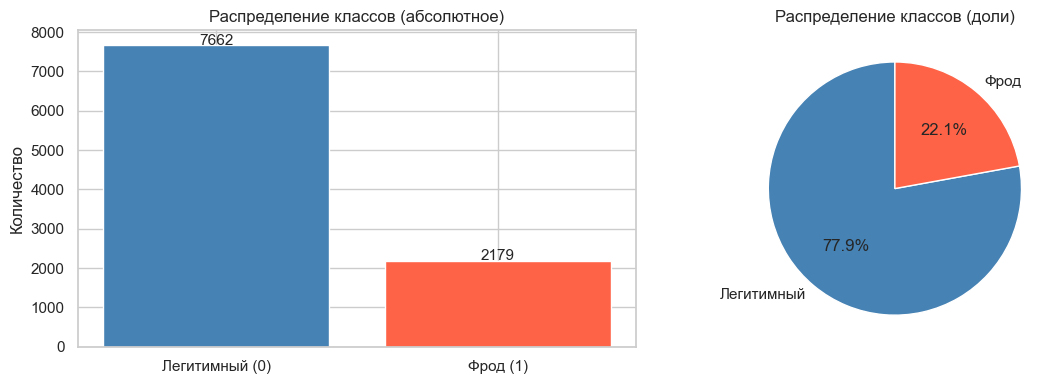


Дисбаланс классов: 3.5:1 (легитимные/фрод)


In [5]:
# ── 3. Распределение целевой переменной ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

vc = df['flag'].value_counts()
axes[0].bar(['Легитимный (0)', 'Фрод (1)'], vc.values,
             color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Распределение классов (абсолютное)')
axes[0].set_ylabel('Количество')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=11)

axes[1].pie(vc.values, labels=['Легитимный', 'Фрод'],
             autopct='%1.1f%%', colors=['steelblue', 'tomato'],
             startangle=90)
axes[1].set_title('Распределение классов (доли)')

plt.tight_layout()
plt.savefig('../report/images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nДисбаланс классов: {vc[0]/vc[1]:.1f}:1 (легитимные/фрод)')

Числовых признаков для анализа: 45


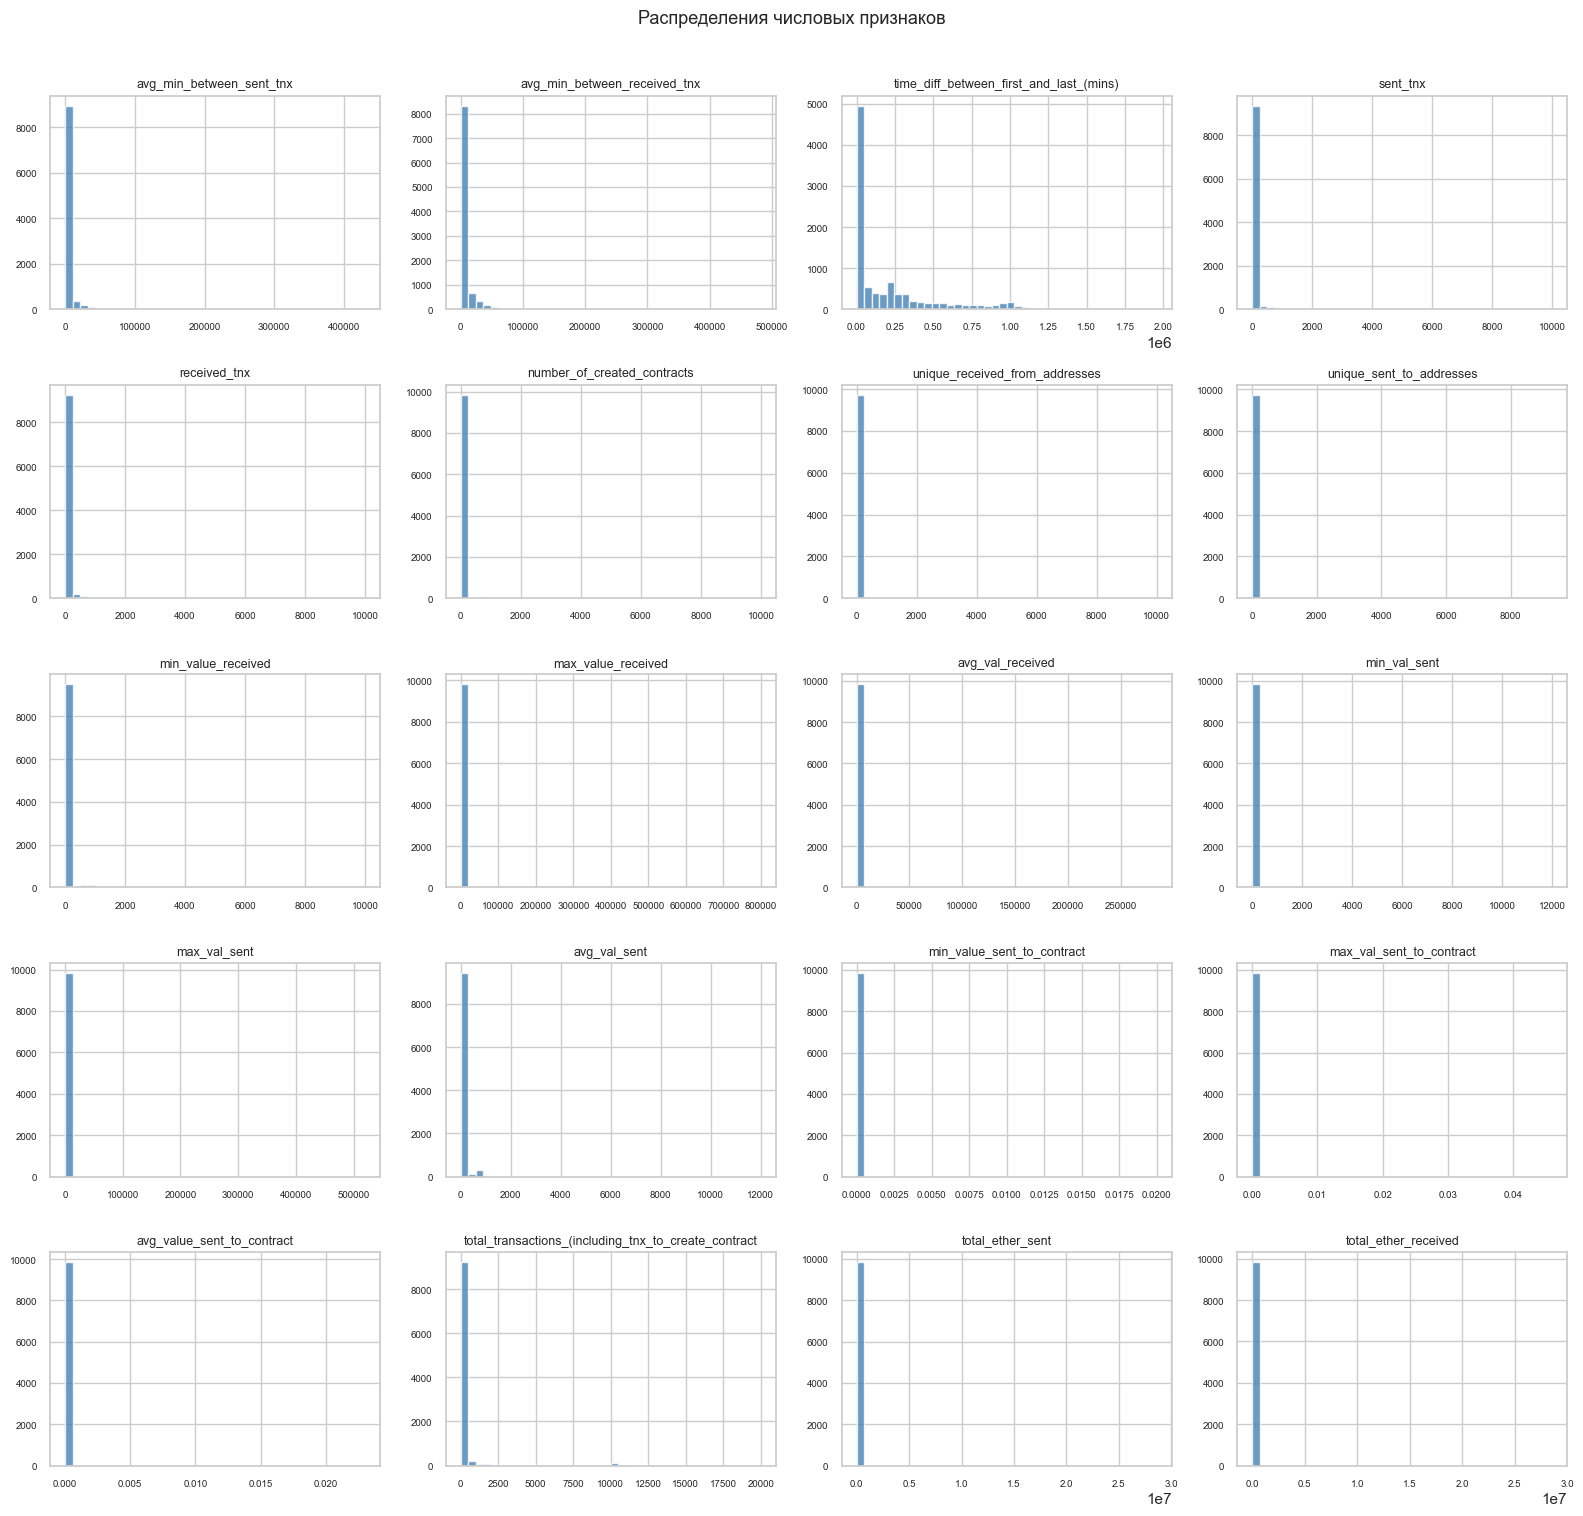


Вывод: большинство признаков имеют сильно скошенное распределение.
Логарифмирование в feature engineering поможет нормализовать их.


In [8]:
# ── 4. Распределения числовых признаков ──────────────────────────────────
# Отбираем числовые колонки (без целевой и ID)
exclude_cols = {'flag', 'unnamed:_0', 'index', 'address',
                'erc20_most_sent_token_type', 'erc20_most_rec_token_type'}
num_cols = [c for c in df.select_dtypes(include='number').columns
            if c not in exclude_cols]

print(f'Числовых признаков для анализа: {len(num_cols)}')

# Рисуем гистограммы первых 20 признаков
plot_cols = num_cols[:20]
n_cols = 4
n_rows = (len(plot_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения числовых признаков', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../report/images/feature_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nВывод: большинство признаков имеют сильно скошенное распределение.\n'
      'Логарифмирование в feature engineering поможет нормализовать их.')

ValueError: The palette dictionary is missing keys: {'0', '1'}

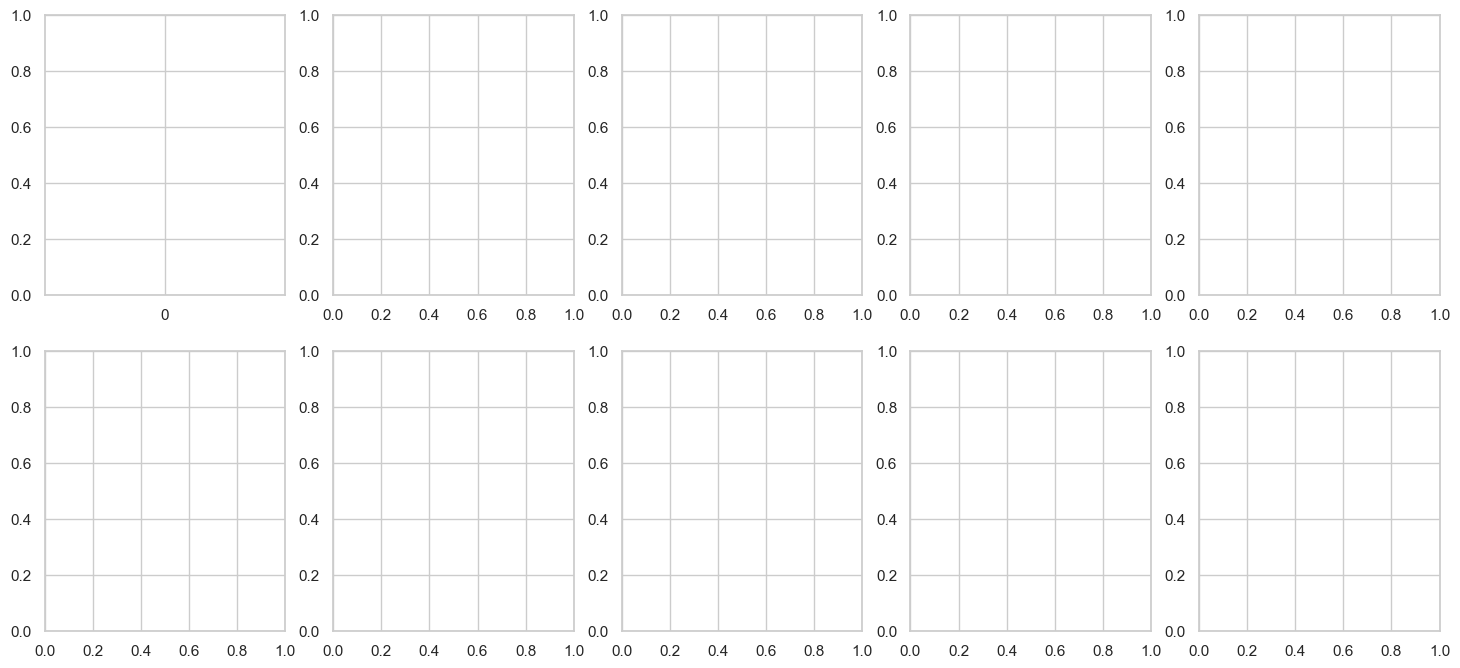

In [9]:
# ── 5. Boxplot для выявления выбросов ─────────────────────────────────────
# Выбираем ключевые транзакционные признаки
key_cols = [
    c for c in [
        'sent_tnx', 'received_tnx',
        'total_ether_sent', 'total_ether_received', 'total_ether_balance',
        'avg_val_sent', 'avg_val_received',
        'number_of_created_contracts',
        'total_erc20_tnxs',
        'min_val_sent_to_contract',
    ]
    if c in df.columns
]

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_cols[:10]):
    # Логарифмическая шкала для лучшей читаемости
    data = df[[col, 'flag']].copy()
    data[col] = np.log1p(data[col].clip(lower=0))
    sns.boxplot(
        data=data, x='flag', y=col,
        palette={0: 'steelblue', 1: 'tomato'},
        ax=axes[i], showfliers=True, flierprops={'markersize': 2}
    )
    axes[i].set_title(f'log1p({col})', fontsize=8)
    axes[i].set_xlabel('Класс (0=легит, 1=фрод)', fontsize=7)

plt.suptitle('Boxplot ключевых признаков (log-scale) по классам', fontsize=12)
plt.tight_layout()
plt.savefig('../report/images/boxplots_by_class.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nВывод: фрод-адреса (класс 1) имеют значительно больше выбросов в размерах транзакций\n'
      'и нетипичное соотношение отправленных/полученных переводов.')

In [ ]:
# ── 6. Корреляционная матрица ─────────────────────────────────────────────
numeric_df = df[num_cols].copy()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(
    numeric_df.corr(), mask=mask, cmap='coolwarm',
    vmin=-1, vmax=1, center=0,
    annot=False, fmt='.1f',
    linewidths=0.5, ax=ax
)
ax.set_title('Корреляционная матрица числовых признаков', fontsize=12)
plt.tight_layout()
plt.savefig('../report/images/correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── 7. Зависимость признаков от таргета ──────────────────────────────────
# Вычисляем корреляцию каждого признака с флагом
corr_with_target = (
    df[num_cols + ['flag']]
    .corr()['flag']
    .drop('flag')
    .abs()
    .sort_values(ascending=False)
)

top_features = corr_with_target.head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_features[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('|Корреляция Пирсона| с FLAG')
ax.set_title('Топ-15 признаков по корреляции с целевой переменной')
ax.axvline(0.1, color='red', linestyle='--', alpha=0.5, label='|corr|=0.1')
ax.legend()
plt.tight_layout()
plt.savefig('../report/images/feature_target_correlation.png', dpi=120, bbox_inches='tight')
plt.show()

print('Топ-5 признаков, наиболее связанных с фродом:')
print(top_features.head(5).to_string())

In [ ]:
# Распределения топ-6 признаков отдельно для каждого класса (KDE + histogram)
top6 = top_features.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(top6):
    for label, color, lbl in [(0, 'steelblue', 'Легитимный'), (1, 'tomato', 'Фрод')]:
        data = np.log1p(df.loc[df['flag'] == label, col].clip(lower=0))
        axes[i].hist(data, bins=40, alpha=0.5, color=color, label=lbl, density=True)
    axes[i].set_title(f'log1p({col})', fontsize=9)
    axes[i].legend(fontsize=7)
    axes[i].set_ylabel('Плотность')

plt.suptitle('Распределения топ-6 признаков по классам (log-scale)', fontsize=12)
plt.tight_layout()
plt.savefig('../report/images/top_features_by_class.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nВывод: распределения топ-признаков заметно различаются между классами,\n'
      'что подтверждает их высокую предсказательную силу.')

## Выводы EDA

1. **Дисбаланс классов:** ~78% легитимных vs ~22% фрод-адресов. Необходима стратифицированная выборка.
2. **Пропуски:** Основные пропуски в ERC20-признаках (~40-60%) — адреса, не работавшие с токенами. Заполняем нулями.
3. **Выбросы:** Все транзакционные признаки имеют экстремальные выбросы (фрод-адреса). Логарифмирование снижает их влияние.
4. **Информативные признаки:** Наибольшую корреляцию с FLAG показывают ERC20-активность и транзакционные паттерны.
5. **Распределения:** Большинство признаков right-skewed — логарифмирование в FE оправдано.
6. **Корреляции:** Ряд ERC20-признаков сильно коррелируют между собой → возможно уменьшение размерности (PCA проверяется в 03_experiments.ipynb).